<a href="https://colab.research.google.com/github/falyseck/activity-recognition/blob/main/HMM_Activity_Recognition_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Human Activity Recognition Using Hidden Markov Models
**Activities:** Still | Standing | Walking | Jumping  
**Sensors:** Accelerometer (x, y, z) + Gyroscope (x, y, z)  
**App:** Sensor Logger — separate Accelerometer.csv and Gyroscope.csv per recording  
**Sampling Rate:** ~100 Hz (from device), resampled to 50 Hz

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Install Dependencies

In [ ]:
!pip install hmmlearn scikit-learn pandas numpy matplotlib seaborn scipy -q

## 1. Imports & Configuration

In [ ]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.fft import fft, fftfreq
from scipy.signal import welch, resample
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# ── Configuration ──────────────────────────────────────────────
TARGET_HZ    = 50           # resample everything to this rate
WINDOW_SIZE  = 50           # 1-second windows at 50 Hz
OVERLAP      = 25           # 50% overlap → step of 25 samples
N_HMM_STATES = 4            # internal states per per-class HMM
N_ITER       = 200          # Baum-Welch iterations
RANDOM_STATE = 42

ACTIVITY_LABELS = {0: 'Still', 1: 'Standing', 2: 'Walking', 3: 'Jumping'}
COLORS = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# ── Folder layout (create this structure) ──────────────────────
# data/
#   train/
#     still/      ← put Accelerometer.csv + Gyroscope.csv pairs here
#     standing/      numbered like Accelerometer(1).csv / Gyroscope(1).csv
#     walking/
#     jumping/
#   test/          ← new recording session (unseen data)
#     still/ standing/ walking/ jumping/
DATA_ROOT = '/content/drive/MyDrive/data'

print('Libraries loaded.')
print(f'Window: {WINDOW_SIZE} samples = {WINDOW_SIZE/TARGET_HZ:.1f} s at {TARGET_HZ} Hz')

Libraries loaded.
Window: 50 samples = 1.0 s at 50 Hz


## 2. Data Loading

Your app exports **separate** `Accelerometer*.csv` and `Gyroscope*.csv` files.  
This section pairs them, merges on time, and resamples to 50 Hz.

**File naming convention your app uses:**
```
Accelerometer.csv   ↔  Gyroscope.csv       (recording 1, base name)
Accelerometer(1).csv ↔ Gyroscope(1).csv    (recording 2)
Accelerometer(2).csv ↔ Gyroscope(2).csv    (recording 3)
...and so on
```

In [ ]:
def parse_recording_index(filename: str) -> str:
    """
    Extract the index key from filenames like:
      Accelerometer.csv      → 'base'
      Accelerometer(1).csv   → '1'
      Accelerometer(2).csv   → '2'
    """
    m = re.search(r'\((\d+)\)', filename)
    return m.group(1) if m else 'base'


def load_and_merge(acc_path: str, gyr_path: str, target_hz: int = TARGET_HZ) -> pd.DataFrame:
    """
    Load one Accelerometer + Gyroscope CSV pair, merge by nearest timestamp,
    then resample to target_hz.

    Input CSV columns: time (ns), seconds_elapsed, z, y, x
    Output columns:    ax, ay, az, gx, gy, gz
    """
    acc = pd.read_csv(acc_path)
    gyr = pd.read_csv(gyr_path)

    # Rename to avoid collisions
    acc = acc.rename(columns={'x': 'ax', 'y': 'ay', 'z': 'az',
                               'seconds_elapsed': 'acc_t'})[['time', 'acc_t', 'ax', 'ay', 'az']]
    gyr = gyr.rename(columns={'x': 'gx', 'y': 'gy', 'z': 'gz',
                               'seconds_elapsed': 'gyr_t'})[['time', 'gyr_t', 'gx', 'gy', 'gz']]

    # Sort by timestamp
    acc = acc.sort_values('time').reset_index(drop=True)
    gyr = gyr.sort_values('time').reset_index(drop=True)

    # Merge-as-of: match each acc row to nearest gyr row in time
    merged = pd.merge_asof(acc, gyr, on='time', direction='nearest')
    merged = merged.dropna().reset_index(drop=True)

    # Use acc_t as the time axis (seconds from start)
    t = merged['acc_t'].values
    duration = t[-1] - t[0]
    n_target = max(1, int(round(duration * target_hz)))

    # Resample each channel to exactly n_target samples
    result = {}
    for col in ['ax', 'ay', 'az', 'gx', 'gy', 'gz']:
        result[col] = resample(merged[col].values, n_target)

    return pd.DataFrame(result)


def find_pairs(folder: str) -> list[tuple[str, str, str]]:
    """
    Find all (acc_path, gyr_path, key) pairs in a folder.
    Matches Accelerometer*.csv with Gyroscope*.csv by their index suffix.
    """
    acc_files = sorted(glob.glob(os.path.join(folder, 'Accelerometer*.csv')))
    pairs = []
    for acc_path in acc_files:
        key = parse_recording_index(os.path.basename(acc_path))
        # Build the expected gyroscope filename
        if key == 'base':
            gyr_path = os.path.join(folder, 'Gyroscope.csv')
        else:
            gyr_path = os.path.join(folder, f'Gyroscope({key}).csv')
        if os.path.exists(gyr_path):
            pairs.append((acc_path, gyr_path, key))
        else:
            print(f'  [WARN] No matching gyroscope for {os.path.basename(acc_path)}')
    return pairs


def load_activity_folder(folder: str, label: int) -> list[tuple[pd.DataFrame, int]]:
    """Load all recording pairs from one activity folder."""
    pairs = find_pairs(folder)
    samples = []
    for acc_path, gyr_path, key in pairs:
        try:
            df = load_and_merge(acc_path, gyr_path)
            samples.append((df, label))
            print(f'  Pair [{key}]: {len(df)} samples @ {TARGET_HZ} Hz')
        except Exception as e:
            print(f'  [ERROR] pair [{key}]: {e}')
    return samples


def load_dataset(root: str) -> tuple[list, list]:
    """Load train and test splits."""
    splits = {}
    for split in ['train', 'test']:
        data = []
        for label_id, name in ACTIVITY_LABELS.items():
            folder = os.path.join(root, split, name.lower())
            if not os.path.exists(folder):
                print(f'[WARN] Missing folder: {folder}')
                continue
            print(f'\n{split.upper()} / {name}:')
            data.extend(load_activity_folder(folder, label_id))
        splits[split] = data
    return splits.get('train', []), splits.get('test', [])


if os.path.exists(DATA_ROOT):
    train_data, test_data = load_dataset(DATA_ROOT)
    print(f'\nLoaded {len(train_data)} train recordings, {len(test_data)} test recordings.')
    USE_SYNTHETIC = (len(train_data) == 0)
else:
    print('[INFO] No data/ folder — using synthetic demo data.')
    USE_SYNTHETIC = True


TRAIN / Still:
  Pair [1]: 345 samples @ 50 Hz
  Pair [2]: 354 samples @ 50 Hz
  Pair [3]: 328 samples @ 50 Hz
  Pair [4]: 351 samples @ 50 Hz
  Pair [base]: 549 samples @ 50 Hz

TRAIN / Standing:
  Pair [1]: 396 samples @ 50 Hz
  Pair [2]: 384 samples @ 50 Hz
  Pair [3]: 381 samples @ 50 Hz
  Pair [4]: 381 samples @ 50 Hz
  Pair [base]: 351 samples @ 50 Hz

TRAIN / Walking:
  Pair [1]: 370 samples @ 50 Hz
  Pair [2]: 345 samples @ 50 Hz
  Pair [3]: 394 samples @ 50 Hz
  Pair [4]: 388 samples @ 50 Hz
  Pair [base]: 371 samples @ 50 Hz

TRAIN / Jumping:
  Pair [1]: 386 samples @ 50 Hz
  Pair [2]: 369 samples @ 50 Hz
  Pair [3]: 389 samples @ 50 Hz
  Pair [4]: 429 samples @ 50 Hz
  Pair [base]: 377 samples @ 50 Hz

TEST / Still:
  Pair [base]: 338 samples @ 50 Hz

TEST / Standing:
  Pair [base]: 370 samples @ 50 Hz

TEST / Walking:
  Pair [base]: 413 samples @ 50 Hz

TEST / Jumping:
  Pair [base]: 385 samples @ 50 Hz

Loaded 20 train recordings, 4 test recordings.


### 2b. Synthetic Fallback (runs automatically if no data/ folder found)

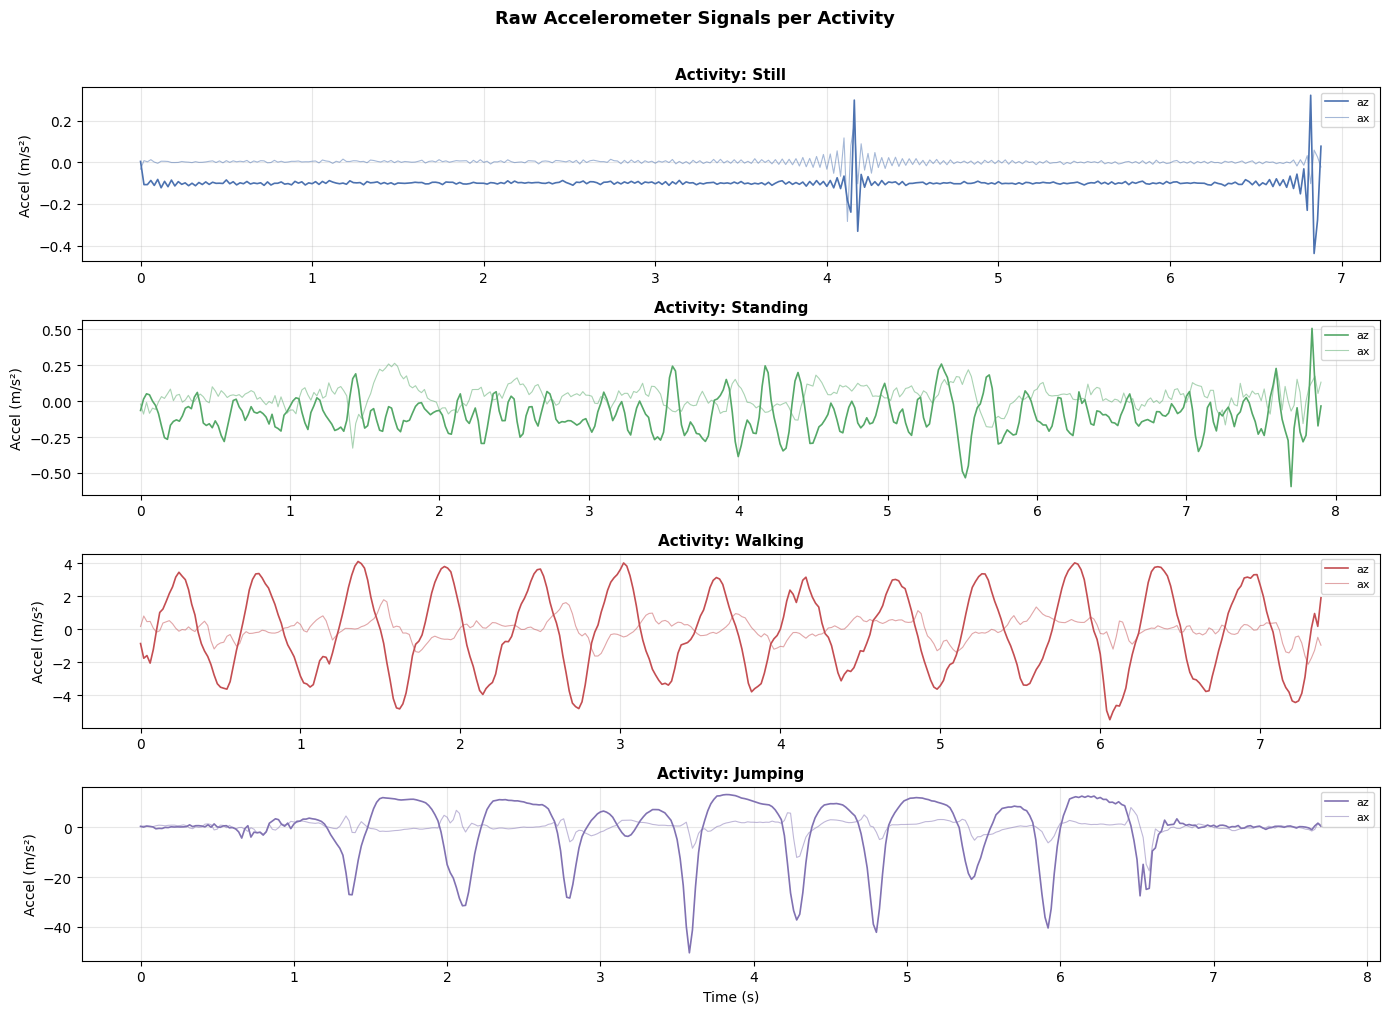

Saved raw_signals.png


In [ ]:
def make_synthetic_signal(activity: str, duration_s: float = 10.0,
                           fs: int = TARGET_HZ, noise: float = 0.05) -> pd.DataFrame:
    np.random.seed()
    n = int(duration_s * fs)
    t = np.linspace(0, duration_s, n)

    if activity == 'still':
        ax = np.random.normal(0, 0.02, n)
        ay = np.random.normal(0, 0.02, n)
        az = np.random.normal(9.81, 0.03, n)
        gx = np.random.normal(0, 0.01, n)
        gy = np.random.normal(0, 0.01, n)
        gz = np.random.normal(0, 0.01, n)
    elif activity == 'standing':
        ax = np.random.normal(0, 0.05, n)
        ay = np.random.normal(0, 0.05, n)
        az = np.random.normal(9.81, 0.08, n)
        gx = np.random.normal(0, 0.03, n)
        gy = np.random.normal(0, 0.03, n)
        gz = np.random.normal(0, 0.03, n)
    elif activity == 'walking':
        f = 1.8
        ax = 0.8*np.sin(2*np.pi*f*t) + np.random.normal(0, noise, n)
        ay = 0.4*np.sin(2*np.pi*f*t + np.pi/4) + np.random.normal(0, noise, n)
        az = 9.81 + 1.2*np.sin(2*np.pi*f*t + np.pi/2) + np.random.normal(0, noise, n)
        gx = 0.3*np.sin(2*np.pi*f*t) + np.random.normal(0, noise/2, n)
        gy = 0.2*np.sin(2*np.pi*f*t + np.pi/3) + np.random.normal(0, noise/2, n)
        gz = 0.1*np.cos(2*np.pi*f*t) + np.random.normal(0, noise/2, n)
    elif activity == 'jumping':
        f = 1.5
        ax = 0.5*np.random.normal(0, 0.3, n)
        ay = 0.5*np.random.normal(0, 0.3, n)
        az = 9.81 + 4.0*np.abs(np.sin(2*np.pi*f*t)) + np.random.normal(0, noise*2, n)
        gx = 1.0*np.sin(2*np.pi*f*t) + np.random.normal(0, noise, n)
        gy = 0.8*np.cos(2*np.pi*f*t) + np.random.normal(0, noise, n)
        gz = 0.5*np.sin(2*np.pi*f*t) + np.random.normal(0, noise, n)
    else:
        raise ValueError(activity)

    return pd.DataFrame({'ax': ax, 'ay': ay, 'az': az,
                          'gx': gx, 'gy': gy, 'gz': gz})


if USE_SYNTHETIC:
    print('Generating synthetic dataset...')
    train_data, test_data = [], []
    for label_id, name in ACTIVITY_LABELS.items():
        for _ in range(20):
            train_data.append((make_synthetic_signal(name.lower()), label_id))
        for _ in range(5):
            test_data.append((make_synthetic_signal(name.lower()), label_id))
    print(f'Synthetic: {len(train_data)} train + {len(test_data)} test recordings.')

# ── Quick sanity plot ──────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=False)
for i, (label_id, name) in enumerate(ACTIVITY_LABELS.items()):
    df_s = next(df for df, lbl in train_data if lbl == label_id)
    t = np.arange(len(df_s)) / TARGET_HZ
    axes[i].plot(t, df_s['az'], label='az', color=COLORS[i], linewidth=1.2)
    axes[i].plot(t, df_s['ax'], label='ax', color=COLORS[i], alpha=0.5, linewidth=0.8)
    axes[i].set_title(f'Activity: {name}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Accel (m/s²)')
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('Time (s)')
plt.suptitle('Raw Accelerometer Signals per Activity', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved raw_signals.png')

## 3. Feature Extraction
Sliding window (1 s, 50% overlap) → 79 features per window.

In [ ]:
def dominant_frequency(sig, fs):
    freqs = fftfreq(len(sig), d=1/fs)
    mags  = np.abs(fft(sig))
    pos   = freqs > 0
    return float(freqs[pos][np.argmax(mags[pos])]) if pos.any() else 0.0

def spectral_energy(sig, fs):
    _, psd = welch(sig, fs=fs, nperseg=min(len(sig), 32))
    return float(np.sum(psd))


def extract_window_features(window: pd.DataFrame, fs: int = TARGET_HZ) -> np.ndarray:
    """
    79 features:
      Time-domain per axis (6 axes × 10 stats = 60)
      Signal-level: SMA + magnitude mean/std/max (4)
      Frequency-domain per axis (6 × 2 = 12)
      Cross-axis correlations ax-ay, ax-az, ay-az (3)
    """
    axes_cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
    feats = []

    # Time-domain
    for col in axes_cols:
        s = window[col].values
        feats += [
            np.mean(s), np.std(s), np.var(s),
            np.min(s), np.max(s), np.ptp(s),
            np.sqrt(np.mean(s**2)),
            float(stats.skew(s)),
            float(stats.kurtosis(s)),
            float(np.mean(np.diff(np.sign(s)) != 0)),
        ]

    # SMA + magnitude
    sma = np.sum(np.abs(window[['ax','ay','az']].values)) / len(window)
    mag = np.sqrt(window['ax']**2 + window['ay']**2 + window['az']**2)
    feats += [sma, np.mean(mag), np.std(mag), np.max(mag)]

    # Frequency-domain
    for col in axes_cols:
        s = window[col].values
        feats += [dominant_frequency(s, fs), spectral_energy(s, fs)]

    # Correlations
    feats.append(float(np.corrcoef(window['ax'], window['ay'])[0,1]))
    feats.append(float(np.corrcoef(window['ax'], window['az'])[0,1]))
    feats.append(float(np.corrcoef(window['ay'], window['az'])[0,1]))

    return np.array(feats, dtype=np.float32)


def extract_features(recordings, window_size=WINDOW_SIZE, overlap=OVERLAP):
    step = window_size - overlap
    all_feats, all_labels, lengths = [], [], []
    for df, label in recordings:
        count = 0
        for start in range(0, len(df) - window_size + 1, step):
            w = df.iloc[start:start+window_size]
            f = extract_window_features(w)
            if not (np.any(np.isnan(f)) or np.any(np.isinf(f))):
                all_feats.append(f)
                all_labels.append(label)
                count += 1
        if count > 0:
            lengths.append(count)
    return np.vstack(all_feats), np.array(all_labels, dtype=int), lengths


print('Extracting training features...')
X_train, y_train, train_lengths = extract_features(train_data)
print(f'Train: {X_train.shape}  ({X_train.shape[1]} features)')

print('Extracting test features...')
X_test, y_test, test_lengths = extract_features(test_data)
print(f'Test:  {X_test.shape}')

for i, name in ACTIVITY_LABELS.items():
    print(f'  {name:10s}: {np.sum(y_train==i):4d} train windows')

Extracting training features...
Train: (276, 79)  (79 features)
Extracting test features...
Test:  (54, 79)
  Still     :   70 train windows
  Standing  :   69 train windows
  Walking   :   66 train windows
  Jumping   :   71 train windows


## 4. Normalisation

In [ ]:
scaler = StandardScaler()
X_train_s = np.nan_to_num(scaler.fit_transform(X_train), nan=0.0, posinf=3.0, neginf=-3.0)
X_test_s  = np.nan_to_num(scaler.transform(X_test),      nan=0.0, posinf=3.0, neginf=-3.0)
print(f'Scaled. Train mean={X_train_s.mean():.4f}, std={X_train_s.std():.4f}')

Scaled. Train mean=0.0000, std=1.0000


## 5. HMM Training — Baum–Welch Algorithm

One Gaussian HMM per activity class. Each has `N_HMM_STATES` internal states  
representing sub-phases of the activity (e.g. swing vs. stance for walking).

In [ ]:
models = {}

# Map from original recording index to its label
# This helps in filtering `train_lengths` correctly later.
recording_labels = [lbl for _, lbl in train_data]

for label_id, name in ACTIVITY_LABELS.items():
    idx = y_train == label_id
    X_cls = X_train_s[idx]

    # Correctly build per-recording lengths for the current class
    # `train_lengths` holds the number of windows for each original recording in `train_data`.
    # We need to filter these lengths to only include those that belong to the current `label_id`.
    lengths_cls = [
        train_lengths[i] for i, lbl in enumerate(recording_labels) if lbl == label_id
    ]

    model = hmm.GaussianHMM(
        n_components=N_HMM_STATES,
        covariance_type='diag',
        n_iter=N_ITER,
        random_state=RANDOM_STATE,
        verbose=False,
    )
    model.fit(X_cls, lengths_cls)
    models[label_id] = model
    print(f'HMM [{name:10s}] trained — log-likelihood = {model.score(X_cls):.2f}')

print('\nAll models trained via Baum–Welch.')

HMM [Still     ] trained — log-likelihood = 10175.59
HMM [Standing  ] trained — log-likelihood = 8315.50
HMM [Walking   ] trained — log-likelihood = 4611.58
HMM [Jumping   ] trained — log-likelihood = -4867.46

All models trained via Baum–Welch.


## 6. Inference — Viterbi Decoding

In [ ]:
def predict_activity(X_seq):
    """Pick the class HMM with the highest log-likelihood; decode with Viterbi."""
    best_score, best_label, best_states = -np.inf, -1, None
    for label_id, model in models.items():
        try:
            score = model.score(X_seq)
            if score > best_score:
                best_score = score
                best_label = label_id
                _, best_states = model.decode(X_seq, algorithm='viterbi')
        except Exception:
            pass
    return best_label, best_states


def predict_all(X, lengths):
    y_pred, all_states = [], []
    start = 0
    for length in lengths:
        label, states = predict_activity(X[start:start+length])
        y_pred.extend([label] * length)
        all_states.extend(list(states) if states is not None else [0]*length)
        start += length
    return np.array(y_pred), all_states


print('Decoding test set (Viterbi)...')
y_pred_test, viterbi_test = predict_all(X_test_s, test_lengths)

print('Decoding train set (sanity check)...')
y_pred_train, _ = predict_all(X_train_s, train_lengths)
print('Done.')

Decoding test set (Viterbi)...
Decoding train set (sanity check)...
Done.


## 7. Visualisations
### 7a. Transition Matrix Heatmaps

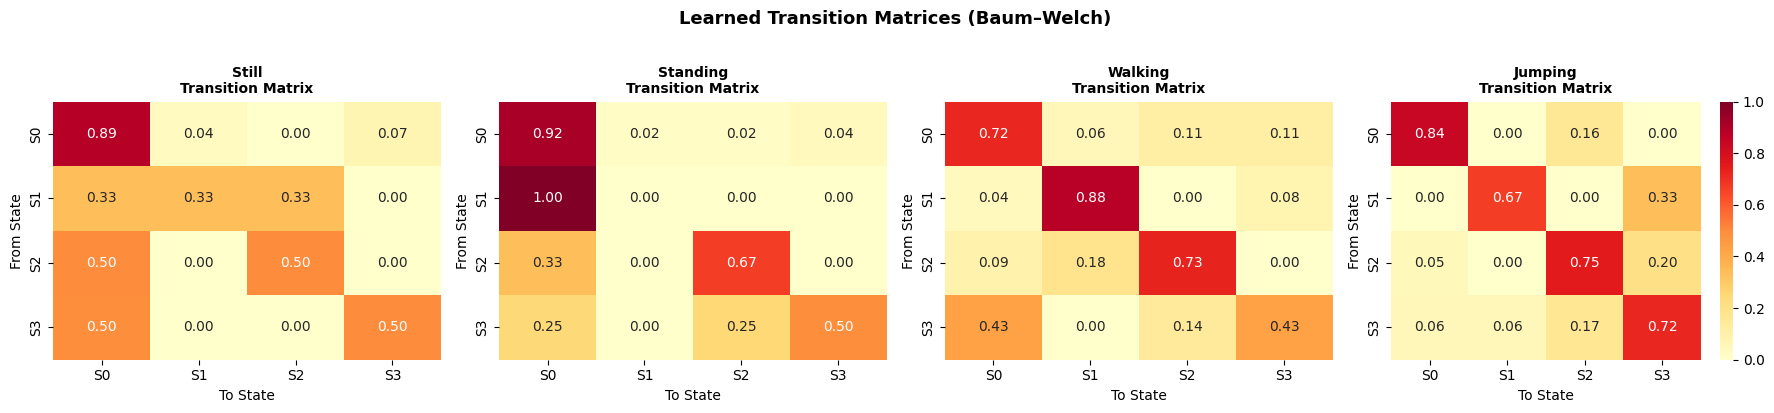

Saved transition_matrices.png


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax_i, (label_id, name) in zip(axes, ACTIVITY_LABELS.items()):
    trans = models[label_id].transmat_
    sns.heatmap(trans, ax=ax_i, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=[f'S{i}' for i in range(N_HMM_STATES)],
                yticklabels=[f'S{i}' for i in range(N_HMM_STATES)],
                vmin=0, vmax=1, cbar=(ax_i is axes[-1]))
    ax_i.set_title(f'{name}\nTransition Matrix', fontsize=10, fontweight='bold')
    ax_i.set_xlabel('To State')
    ax_i.set_ylabel('From State')
plt.suptitle('Learned Transition Matrices (Baum–Welch)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('transition_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved transition_matrices.png')

### 7b. Viterbi Decoded Sequence

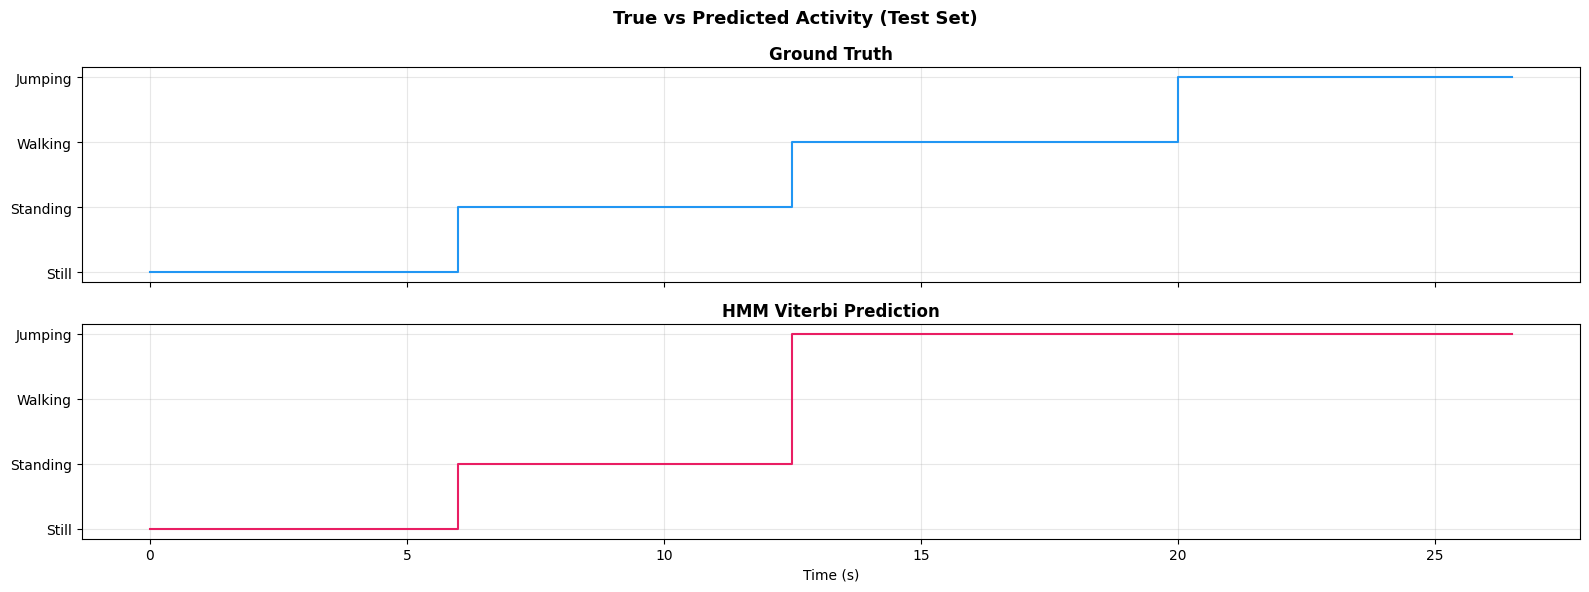

Saved decoded_sequence.png


In [ ]:
n_eval = min(len(y_test), len(y_pred_test))
n_plot = min(300, n_eval)
t_ax   = np.arange(n_plot) * (WINDOW_SIZE - OVERLAP) / TARGET_HZ

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
ax1.step(t_ax, y_test[:n_plot],       where='post', color='#2196F3', lw=1.5)
ax2.step(t_ax, y_pred_test[:n_plot],  where='post', color='#E91E63', lw=1.5)
for ax_i, title in [(ax1, 'Ground Truth'), (ax2, 'HMM Viterbi Prediction')]:
    ax_i.set_yticks(range(4))
    ax_i.set_yticklabels(ACTIVITY_LABELS.values())
    ax_i.set_title(title, fontweight='bold')
    ax_i.grid(True, alpha=0.3)
ax2.set_xlabel('Time (s)')
plt.suptitle('True vs Predicted Activity (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('decoded_sequence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved decoded_sequence.png')

### 7c. Confusion Matrix

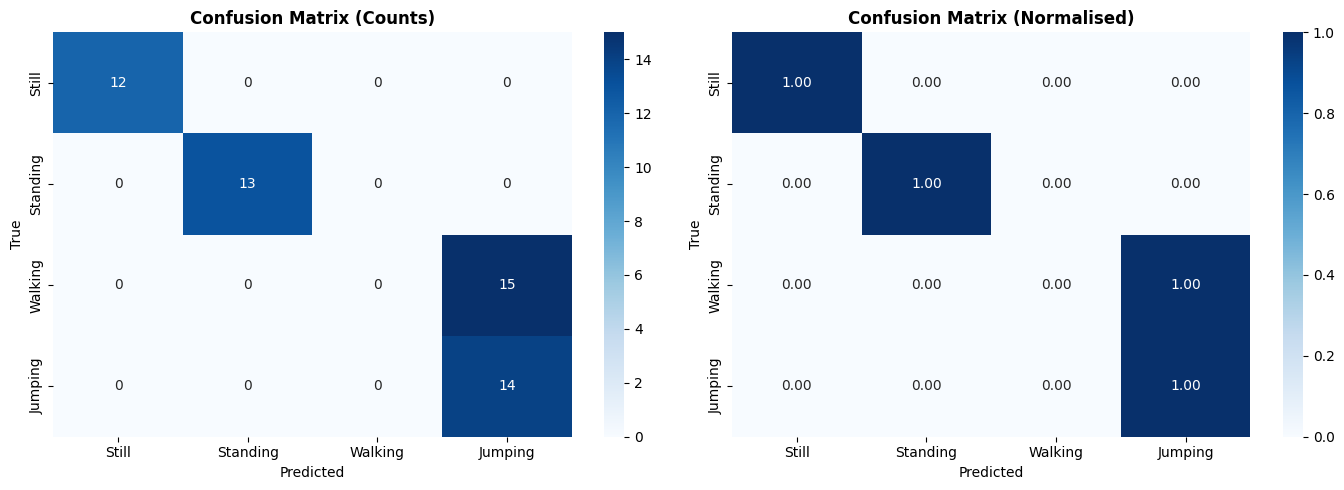

Saved confusion_matrix.png


In [ ]:
cm      = confusion_matrix(y_test[:n_eval], y_pred_test[:n_eval])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_i, (data, title, fmt) in zip(axes,
        [(cm, 'Counts', 'd'), (cm_norm, 'Normalised', '.2f')]):
    sns.heatmap(data, ax=ax_i, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=ACTIVITY_LABELS.values(),
                yticklabels=ACTIVITY_LABELS.values())
    ax_i.set_title(f'Confusion Matrix ({title})', fontweight='bold')
    ax_i.set_xlabel('Predicted'); ax_i.set_ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_matrix.png')

### 7d. Feature Distributions

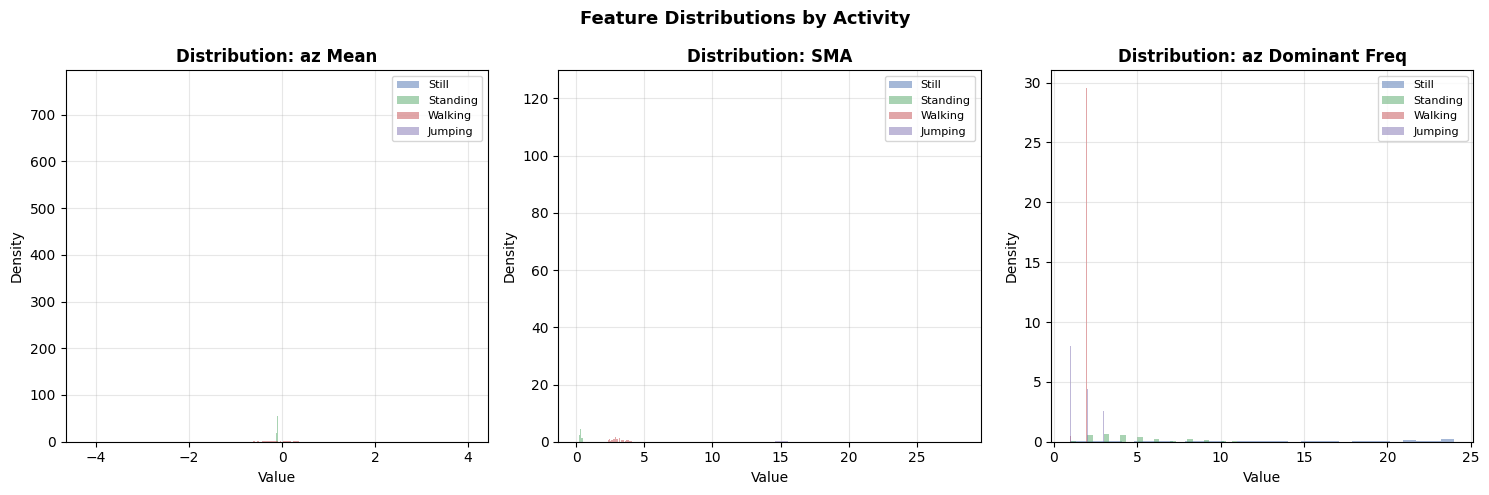

Saved feature_distributions.png


In [ ]:
# az mean=20, SMA=60, az dominant freq=60+4+(2*2)=68
feat_display = [('az Mean', 20), ('SMA', 60), ('az Dominant Freq', 68)]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax_i, (fname, fidx) in zip(axes, feat_display):
    for label_id, name in ACTIVITY_LABELS.items():
        vals = X_train[y_train == label_id, fidx]
        ax_i.hist(vals, bins=30, alpha=0.5, label=name, color=COLORS[label_id], density=True)
    ax_i.set_title(f'Distribution: {fname}', fontweight='bold')
    ax_i.set_xlabel('Value'); ax_i.set_ylabel('Density')
    ax_i.legend(fontsize=8); ax_i.grid(True, alpha=0.3)
plt.suptitle('Feature Distributions by Activity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved feature_distributions.png')

## 8. Evaluation Metrics

In [ ]:
def compute_metrics(y_true, y_pred):
    rows = []
    for label_id, name in ACTIVITY_LABELS.items():
        tp = np.sum((y_true==label_id) & (y_pred==label_id))
        fn = np.sum((y_true==label_id) & (y_pred!=label_id))
        tn = np.sum((y_true!=label_id) & (y_pred!=label_id))
        fp = np.sum((y_true!=label_id) & (y_pred==label_id))
        sens = tp/(tp+fn) if (tp+fn)>0 else 0.0
        spec = tn/(tn+fp) if (tn+fp)>0 else 0.0
        rows.append({'Activity': name,
                     'Samples': int(np.sum(y_true==label_id)),
                     'Sensitivity': f'{sens:.3f}',
                     'Specificity': f'{spec:.3f}'})
    overall = np.mean(y_true == y_pred)
    rows.append({'Activity': 'OVERALL', 'Samples': len(y_true),
                 'Sensitivity': '—', 'Specificity': '—'})
    return pd.DataFrame(rows), overall


metrics_df, overall_acc = compute_metrics(y_test[:n_eval], y_pred_test[:n_eval])
print(f'Overall Accuracy (unseen test): {overall_acc:.1%}\n')
print(metrics_df.to_string(index=False))
print()
print(classification_report(y_test[:n_eval], y_pred_test[:n_eval],
                             target_names=list(ACTIVITY_LABELS.values())))

Overall Accuracy (unseen test): 72.2%

Activity  Samples Sensitivity Specificity
   Still       12       1.000       1.000
Standing       13       1.000       1.000
 Walking       15       0.000       1.000
 Jumping       14       1.000       0.625
 OVERALL       54           —           —

              precision    recall  f1-score   support

       Still       1.00      1.00      1.00        12
    Standing       1.00      1.00      1.00        13
     Walking       0.00      0.00      0.00        15
     Jumping       0.48      1.00      0.65        14

    accuracy                           0.72        54
   macro avg       0.62      0.75      0.66        54
weighted avg       0.59      0.72      0.63        54



## 9. Save All Results

In [ ]:
pd.DataFrame({
    'true_label'   : y_test[:n_eval],
    'pred_label'   : y_pred_test[:n_eval],
    'true_activity': [ACTIVITY_LABELS[i] for i in y_test[:n_eval]],
    'pred_activity': [ACTIVITY_LABELS[i] for i in y_pred_test[:n_eval]],
}).to_csv('predictions.csv', index=False)

metrics_df.to_csv('metrics_table.csv', index=False)

print('predictions.csv  ✓')
print('metrics_table.csv ✓')
print(f'Final accuracy: {overall_acc:.1%}')
print('Notebook complete!')

predictions.csv  ✓
metrics_table.csv ✓
Final accuracy: 72.2%
Notebook complete!
